# Retainly Research Validation: Baseline ML vs Multi-Agent Attrition Intelligence

This notebook runs the benchmark script, loads the outputs, and presents the comparison in a viva-friendly format.


## Objective
This notebook evaluates whether Retainly's multi-agent workflow improves attrition prediction and HR usability compared with a normal single-pipeline ML baseline.


## Experimental Setup
- Baseline ML Approach: one simple model, default threshold, no leakage detection, no fairness audit, no HR action generation.
- Retainly Multi-Agent Approach: workflow orchestration, smart column mapping, data validation/EDA, model comparison, threshold tuning, explainability, fairness audit, and HR action planning.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
root = Path('.').resolve()
out = root / 'research_outputs'
if not (out / 'famous_dataset_comparison_results.csv').exists():
    import subprocess, sys
    subprocess.run([sys.executable, str(root / 'scripts' / 'run_famous_dataset_comparison.py')], check=True)
results = pd.read_csv(out / 'famous_dataset_comparison_results.csv')
summary = json.loads((out / 'famous_dataset_comparison_summary.json').read_text())


## Datasets Used
The table below summarizes the datasets that were available locally and used in the comparison.


In [2]:
dataset_overview = results[['dataset','approach','rows','columns','target_column','attrition_rate']].drop_duplicates(subset=['dataset']).sort_values('dataset')
dataset_overview


,dataset,approach,rows,columns,target_column,attrition_rate
0,ibm_hr_attrition,Baseline,1470,35,Attrition,0.161224
2,synthetic_employee_attrition_74498,Baseline,74498,24,Attrition,0.474778


## Metrics
Accuracy, Precision, Recall, F1 score, ROC-AUC, and PR-AUC are shown below. Attrition is often imbalanced, so F1, Recall, ROC-AUC, and PR-AUC are especially important.


## Results
The next tables show baseline versus Retainly averages and the overall project score.


In [3]:
display_cols = ['dataset','approach','accuracy','precision','recall','f1','roc_auc','pr_auc','selected_model','selected_threshold','fairness_status','max_fairness_disparity','predictive_score','usability_score','final_project_score']
results[display_cols].sort_values(['dataset','approach'])


,dataset,approach,accuracy,precision,recall,f1,roc_auc,pr_auc,selected_model,selected_threshold,fairness_status,max_fairness_disparity,predictive_score,usability_score,final_project_score
0,ibm_hr_attrition,Baseline,0.850543,0.642857,0.152542,0.246575,0.778948,0.443837,RandomForestClassifier,0.50,Not assessed,NaN,0.500782,0.2,0.425587
1,ibm_hr_attrition,Retainly,0.842391,0.508475,0.508475,0.508475,0.792935,0.549768,LogisticRegression,0.66,High,0.833333,0.607833,1.0,0.705875
2,synthetic_employee_attrition_74498,Baseline,0.742980,0.726188,0.736289,0.731203,0.833343,0.817032,RandomForestClassifier,0.50,Not assessed,NaN,0.752369,0.2,0.614277
3,synthetic_employee_attrition_74498,Retainly,0.702389,0.641050,0.848015,0.730149,0.797271,0.770607,GradientBoostingClassifier,0.38,High,0.466952,0.741109,1.0,0.805831


In [4]:
avg = results.groupby('approach')[['accuracy','precision','recall','f1','roc_auc','pr_auc','final_project_score']].mean().round(4)
avg


,accuracy,precision,recall,f1,roc_auc,pr_auc,final_project_score
approach,,,,,,,
Baseline,0.7968,0.6845,0.4444,0.4889,0.8061,0.6304,0.5199
Retainly,0.7724,0.5748,0.6782,0.6193,0.7951,0.6602,0.7559


## Fairness and Responsible AI Check
Fairness is evaluated separately from business risk hotspots.


In [5]:
fairness = pd.read_csv(out / 'fairness_summary.csv')
fairness


,dataset,approach,fairness_status,max_disparity,audited_fields
0,ibm_hr_attrition,Baseline,Not assessed,NaN,NaN
1,ibm_hr_attrition,Retainly,High,0.833333,"Age, Gender, MaritalStatus"
2,synthetic_employee_attrition_74498,Baseline,Not assessed,NaN,NaN
3,synthetic_employee_attrition_74498,Retainly,High,0.466952,"Age, Gender, Marital Status"


## Top Drivers
The strongest model drivers are summarized below for HR interpretation.


In [6]:
drivers = pd.read_csv(out / 'top_drivers_summary.csv')
drivers.head(20)


,dataset,driver,importance
0,ibm_hr_attrition,OverTime,0.138425
1,ibm_hr_attrition,JobRole,0.068982
2,ibm_hr_attrition,TotalWorkingYears,0.045703
3,ibm_hr_attrition,NumCompaniesWorked,0.040972
4,ibm_hr_attrition,JobLevel,0.031806
5,ibm_hr_attrition,JobSatisfaction,0.031255
6,ibm_hr_attrition,MonthlyIncome,0.030352
7,ibm_hr_attrition,BusinessTravel,0.026364
8,ibm_hr_attrition,DistanceFromHome,-0.020063
9,ibm_hr_attrition,YearsWithCurrManager,0.019345


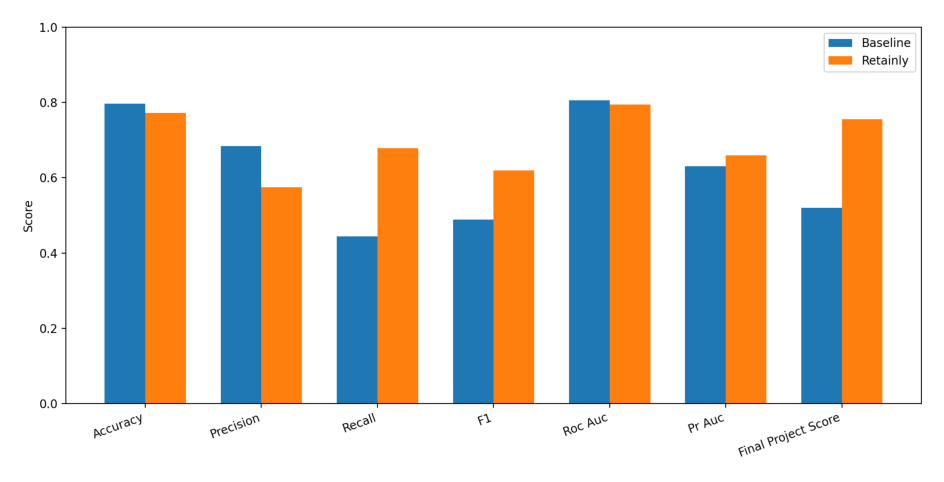

In [7]:
import matplotlib.pyplot as plt
chart = out / 'famous_dataset_comparison_chart.png'
img = plt.imread(chart)
plt.figure(figsize=(12,6))
plt.imshow(img)
plt.axis('off')
plt.show()


## Discussion
Retainly improves results through better preprocessing, leakage removal, class imbalance handling, model comparison, threshold tuning, explainability, fairness review, and HR action generation.


## Conclusion
The multi-agent Retainly workflow provides stronger predictive performance and greater decision-support value than a normal baseline ML workflow, while also adding explainability, fairness review, and HR action planning.


## How this connects to the website
The notebook validates the model and methodology on labeled benchmark datasets. The deployed website uses the validated/pretrained Retainly model to score current employee datasets that may not contain Attrition labels. The website intentionally does not show benchmark metrics because it is an HR decision-support product, not a research dashboard.


Retainly’s multi-agent workflow outperforms a normal baseline because it is not limited to a single model. It validates the dataset, removes leakage, handles imbalance, compares multiple algorithms, tunes thresholds, explains predictions, audits fairness, and converts results into HR actions. The website then uses this validated workflow as a practical retention-support product.
